# 03 — Dataset Generation: 21 cm Power Spectra

Goal: use the LHS parameter table from Notebook 02 to generate a small validation dataset of
21cmFAST coeval simulations and extract Δ²₂₁(k,z) features.

First run:
- MAX_SIMULATIONS = 5

After validation:
- increase to 100.

In [1]:
from pathlib import Path
import json
import time
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import py21cmfast as p21c

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"
LOGS = PROJECT_ROOT / "logs"

for path in [DATA_RAW, DATA_PROCESSED, FIGURES, LOGS]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", DATA_RAW)
print("Processed data:", DATA_PROCESSED)
print("Figures:", FIGURES)
print("Logs:", LOGS)

Project root: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression
Raw data: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw
Processed data: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed
Figures: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures
Logs: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/logs


In [33]:
PARAMETER_TABLE_PATH = DATA_RAW / "lhs_parameter_table_n100.csv"

MAX_SIMULATIONS = 100       # first validation run
N_KBINS = 20
BOX_LEN = 100.0

REDshifts = [8.0, 10.0, 12.0]
REDSHIFTS = REDshifts     # keep uppercase name for consistency later

BASE_RANDOM_SEED = 1234

USER_TEMPLATE = ["simple", "small"]

print("Parameter table:", PARAMETER_TABLE_PATH)
print("MAX_SIMULATIONS:", MAX_SIMULATIONS)
print("Redshifts:", REDSHIFTS)
print("k bins requested:", N_KBINS)

Parameter table: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/raw/lhs_parameter_table_n100.csv
MAX_SIMULATIONS: 100
Redshifts: [8.0, 10.0, 12.0]
k bins requested: 20


In [34]:
parameter_df = pd.read_csv(PARAMETER_TABLE_PATH)

print("Parameter table shape:", parameter_df.shape)
parameter_df.head()

Parameter table shape: (100, 11)


,simulation_id,zeta,log10_Tvir,R_mfp,log10_LX,sigma8,HII_EFF_FACTOR,ION_Tvir_MIN,R_BUBBLE_MAX,L_X,SIGMA_8
0,0,67.558231,4.248417,12.035351,39.932105,0.761859,67.558231,4.248417,12.035351,39.932105,0.761859
1,1,66.017064,5.098583,24.803484,38.834875,0.773324,66.017064,5.098583,24.803484,38.834875,0.773324
2,2,53.140441,4.946099,29.339034,39.807090,0.854335,53.140441,4.946099,29.339034,39.807090,0.854335
3,3,37.140933,5.206681,22.484046,39.646895,0.897553,37.140933,5.206681,22.484046,39.646895,0.897553
4,4,25.569339,5.404682,12.257325,38.124275,0.774332,25.569339,5.404682,12.257325,38.124275,0.774332


In [35]:
run_df = parameter_df.head(MAX_SIMULATIONS).copy()

print("Running simulations:", len(run_df))
run_df[[
    "simulation_id",
    "zeta",
    "log10_Tvir",
    "R_mfp",
    "log10_LX",
    "sigma8"
]]

Running simulations: 100


,simulation_id,zeta,log10_Tvir,R_mfp,log10_LX,sigma8
0,0,67.558231,4.248417,12.035351,39.932105,0.761859
1,1,66.017064,5.098583,24.803484,38.834875,0.773324
2,2,53.140441,4.946099,29.339034,39.807090,0.854335
3,3,37.140933,5.206681,22.484046,39.646895,0.897553
4,4,25.569339,5.404682,12.257325,38.124275,0.774332
...,...,...,...,...,...,...
95,95,18.886707,4.818581,6.097253,41.774615,0.848382
96,96,14.613852,4.266736,28.352923,40.427318,0.764946
97,97,44.707120,4.142888,25.693602,39.097102,0.767151
98,98,46.608598,4.095281,20.836892,38.467351,0.802819


In [36]:
def compute_dimensionless_power_spectrum(field, box_len, n_kbins=20):
    """
    Compute an approximate spherically averaged dimensionless 3D power spectrum.

    This function is used for controlled dataset generation in the early project stage.
    It should later be cross-checked against a dedicated 21cmFAST/powerbox estimator.
    """

    field = np.asarray(field, dtype=float)

    if field.ndim != 3:
        raise ValueError("Input field must be a 3D array.")

    if not np.all(np.isfinite(field)):
        raise ValueError("Input field contains NaN or infinite values.")

    if field.shape[0] != field.shape[1] or field.shape[0] != field.shape[2]:
        raise ValueError("Input field must be cubic.")

    n = field.shape[0]

    fluct = field - np.mean(field)

    fft_field = np.fft.fftn(fluct)
    power_3d = np.abs(fft_field) ** 2 / n**6 * box_len**3

    kfreq = 2.0 * np.pi * np.fft.fftfreq(n, d=box_len / n)
    kx, ky, kz = np.meshgrid(kfreq, kfreq, kfreq, indexing="ij")
    k_mag = np.sqrt(kx**2 + ky**2 + kz**2)

    k_flat = k_mag.ravel()
    p_flat = power_3d.ravel()

    positive = k_flat > 0
    k_flat = k_flat[positive]
    p_flat = p_flat[positive]

    k_edges = np.logspace(
        np.log10(k_flat.min()),
        np.log10(k_flat.max()),
        n_kbins + 1
    )

    k_centers = np.sqrt(k_edges[:-1] * k_edges[1:])
    p_k = np.full(n_kbins, np.nan)

    for i in range(n_kbins):
        mask = (k_flat >= k_edges[i]) & (k_flat < k_edges[i + 1])
        if np.any(mask):
            p_k[i] = np.mean(p_flat[mask])

    delta2 = (k_centers**3 * p_k) / (2.0 * np.pi**2)

    valid = np.isfinite(delta2)

    return k_centers[valid], delta2[valid]

In [37]:
def run_single_parameter_point(row, redshifts, n_kbins=20):
    """
    Run one 21cmFAST parameter point and return:
    - flattened feature vector
    - tidy power-spectrum rows
    - feature names
    """

    simulation_id = int(row["simulation_id"])
    random_seed = BASE_RANDOM_SEED + simulation_id

    inputs = p21c.InputParameters.from_template(
        USER_TEMPLATE,
        random_seed=random_seed,

        # Astrophysical parameters
        HII_EFF_FACTOR=float(row["HII_EFF_FACTOR"]),
        ION_Tvir_MIN=float(row["ION_Tvir_MIN"]),
        R_BUBBLE_MAX=float(row["R_BUBBLE_MAX"]),
        L_X=float(row["L_X"]),

        # Cosmological parameter
        SIGMA_8=float(row["SIGMA_8"]),
    )

    coeval_list = p21c.run_coeval(
        inputs=inputs,
        out_redshifts=redshifts,
        write=False,
        progressbar=False,
    )

    coeval_boxes = {box.redshift: box for box in coeval_list}

    feature_values = []
    feature_names = []
    power_rows = []

    for z in sorted(coeval_boxes.keys(), reverse=True):
        box = coeval_boxes[z]
        field = box.brightness_temp

        k, delta2 = compute_dimensionless_power_spectrum(
            field=field,
            box_len=BOX_LEN,
            n_kbins=n_kbins,
        )

        for k_val, delta_val in zip(k, delta2):
            feature_values.append(delta_val)
            feature_names.append(f"delta2_z{z:.1f}_k{k_val:.5f}")

            power_rows.append({
                "simulation_id": simulation_id,
                "z": z,
                "k": k_val,
                "delta2_21": delta_val,
            })

    feature_values = np.array(feature_values, dtype=float)

    return feature_values, power_rows, feature_names

In [38]:
test_row = run_df.iloc[0]

test_feature_vector, test_power_rows, test_feature_names = run_single_parameter_point(
    row=test_row,
    redshifts=REDSHIFTS,
    n_kbins=N_KBINS,
)

print("Test simulation ID:", int(test_row["simulation_id"]))
print("Feature vector shape:", test_feature_vector.shape)
print("Number of power rows:", len(test_power_rows))
print("Number of feature names:", len(test_feature_names))
print("First five feature names:", test_feature_names[:5])
print("First five feature values:", test_feature_vector[:5])

Test simulation ID: 0
Feature vector shape: (57,)
Number of power rows: 57
Number of feature names: 57
First five feature names: ['delta2_z12.0_k0.08491', 'delta2_z12.0_k0.10379', 'delta2_z12.0_k0.12686', 'delta2_z12.0_k0.15507', 'delta2_z12.0_k0.18954']
First five feature values: [0.7404197  5.4578029  7.25927563 4.65296522 4.11464321]


In [39]:
all_features = []
all_targets = []
all_power_rows = []
failed_simulations = []

reference_feature_names = None

start_time = time.time()

for idx, row in run_df.iterrows():

    simulation_id = int(row["simulation_id"])

    print("=" * 60)
    print(f"Running simulation_id = {simulation_id}")
    print("=" * 60)

    try:
        feature_vector, power_rows, feature_names = run_single_parameter_point(
            row=row,
            redshifts=REDSHIFTS,
            n_kbins=N_KBINS,
        )

        if reference_feature_names is None:
            reference_feature_names = feature_names
        else:
            assert feature_names == reference_feature_names, (
                "Feature names changed across simulations."
            )

        target_vector = row[[
            "zeta",
            "log10_Tvir",
            "R_mfp",
            "log10_LX",
            "sigma8"
        ]].to_numpy(dtype=float)

        all_features.append(feature_vector)
        all_targets.append(target_vector)
        all_power_rows.extend(power_rows)

        print("Success.")
        print("Feature shape:", feature_vector.shape)

    except Exception as e:
        print("FAILED simulation_id:", simulation_id)
        print("Error:", repr(e))

        failed_simulations.append({
            "simulation_id": simulation_id,
            "error": repr(e),
            "traceback": traceback.format_exc(),
        })

elapsed_time = time.time() - start_time

print("=" * 60)
print("Validation dataset generation finished.")
print("Elapsed time [s]:", elapsed_time)
print("Successful simulations:", len(all_features))
print("Failed simulations:", len(failed_simulations))

Running simulation_id = 0
Success.
Feature shape: (57,)
Running simulation_id = 1
Success.
Feature shape: (57,)
Running simulation_id = 2
Success.
Feature shape: (57,)
Running simulation_id = 3
Success.
Feature shape: (57,)
Running simulation_id = 4
Success.
Feature shape: (57,)
Running simulation_id = 5
Success.
Feature shape: (57,)
Running simulation_id = 6
Success.
Feature shape: (57,)
Running simulation_id = 7
Success.
Feature shape: (57,)
Running simulation_id = 8
Success.
Feature shape: (57,)
Running simulation_id = 9
Success.
Feature shape: (57,)
Running simulation_id = 10
Success.
Feature shape: (57,)
Running simulation_id = 11
Success.
Feature shape: (57,)
Running simulation_id = 12
Success.
Feature shape: (57,)
Running simulation_id = 13
Success.
Feature shape: (57,)
Running simulation_id = 14
Success.
Feature shape: (57,)
Running simulation_id = 15
Success.
Feature shape: (57,)
Running simulation_id = 16
Success.
Feature shape: (57,)
Running simulation_id = 17
Success.
Featu

Success.
Feature shape: (57,)
Running simulation_id = 46
Success.
Feature shape: (57,)
Running simulation_id = 47
Success.
Feature shape: (57,)
Running simulation_id = 48
Success.
Feature shape: (57,)
Running simulation_id = 49
Success.
Feature shape: (57,)
Running simulation_id = 50
Success.
Feature shape: (57,)
Running simulation_id = 51
Success.
Feature shape: (57,)
Running simulation_id = 52
Success.
Feature shape: (57,)
Running simulation_id = 53
Success.
Feature shape: (57,)
Running simulation_id = 54
Success.
Feature shape: (57,)
Running simulation_id = 55
Success.
Feature shape: (57,)
Running simulation_id = 56
Success.
Feature shape: (57,)
Running simulation_id = 57
Success.
Feature shape: (57,)
Running simulation_id = 58
Success.
Feature shape: (57,)
Running simulation_id = 59
Success.
Feature shape: (57,)
Running simulation_id = 60
Success.
Feature shape: (57,)
Running simulation_id = 61
Success.
Feature shape: (57,)
Running simulation_id = 62
Success.
Feature shape: (57,)
R

Success.
Feature shape: (57,)
Running simulation_id = 92
Success.
Feature shape: (57,)
Running simulation_id = 93
Success.
Feature shape: (57,)
Running simulation_id = 94
Success.
Feature shape: (57,)
Running simulation_id = 95
Success.
Feature shape: (57,)
Running simulation_id = 96
Success.
Feature shape: (57,)
Running simulation_id = 97
Success.
Feature shape: (57,)
Running simulation_id = 98
Success.
Feature shape: (57,)
Running simulation_id = 99
Success.
Feature shape: (57,)
Validation dataset generation finished.
Elapsed time [s]: 423.7718949317932
Successful simulations: 100
Failed simulations: 0


In [40]:
X = np.vstack(all_features)
y = np.vstack(all_targets)

power_df = pd.DataFrame(all_power_rows)

target_names = [
    "zeta",
    "log10_Tvir",
    "R_mfp",
    "log10_LX",
    "sigma8"
]

feature_names_df = pd.DataFrame({
    "feature_index": np.arange(len(reference_feature_names)),
    "feature_name": reference_feature_names,
})

target_names_df = pd.DataFrame({
    "target_index": np.arange(len(target_names)),
    "target_name": target_names,
})

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Power-spectrum dataframe shape:", power_df.shape)
print("Feature names shape:", feature_names_df.shape)
print("Target names shape:", target_names_df.shape)

X shape: (100, 57)
y shape: (100, 5)
Power-spectrum dataframe shape: (5700, 4)
Feature names shape: (57, 2)
Target names shape: (5, 2)


In [41]:
assert X.shape[0] == y.shape[0]
assert X.shape[0] == len(run_df) - len(failed_simulations)
assert X.shape[1] == len(reference_feature_names)
assert y.shape[1] == len(target_names)
assert len(power_df) == X.shape[0] * X.shape[1]

assert np.all(np.isfinite(X))
assert np.all(np.isfinite(y))

print("All dataset shapes and finite-value checks passed.")

All dataset shapes and finite-value checks passed.


In [42]:
tag = f"n{MAX_SIMULATIONS}_validation"

feature_matrix_path = DATA_PROCESSED / f"feature_matrix_{tag}.npy"
target_matrix_path = DATA_PROCESSED / f"target_matrix_{tag}.npy"
power_spectra_path = DATA_PROCESSED / f"power_spectra_{tag}.csv"
feature_names_path = DATA_PROCESSED / f"feature_names_{tag}.csv"
target_names_path = DATA_PROCESSED / f"target_names_{tag}.csv"

np.save(feature_matrix_path, X)
np.save(target_matrix_path, y)

power_df.to_csv(power_spectra_path, index=False)
feature_names_df.to_csv(feature_names_path, index=False)
target_names_df.to_csv(target_names_path, index=False)

print("Saved:")
print(" -", feature_matrix_path)
print(" -", target_matrix_path)
print(" -", power_spectra_path)
print(" -", feature_names_path)
print(" -", target_names_path)

Saved:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/feature_matrix_n100_validation.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/target_matrix_n100_validation.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/power_spectra_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/feature_names_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/target_names_n100_validation.csv


In [43]:
generation_metadata = {
    "notebook": "03_dataset_generation_power_spectra.ipynb",
    "parameter_table": str(PARAMETER_TABLE_PATH),
    "max_simulations": MAX_SIMULATIONS,
    "successful_simulations": int(X.shape[0]),
    "failed_simulations": failed_simulations,
    "redshifts": REDSHIFTS,
    "n_kbins_requested": N_KBINS,
    "n_features": int(X.shape[1]),
    "target_names": target_names,
    "base_random_seed": BASE_RANDOM_SEED,
    "user_template": USER_TEMPLATE,
    "elapsed_time_seconds": elapsed_time,
    "notes": (
        "Initial validation dataset generated from coeval 21cmFAST boxes. "
        "This is not yet the final production dataset."
    ),
}

metadata_path = DATA_PROCESSED / f"dataset_generation_metadata_{tag}.json"

with open(metadata_path, "w") as f:
    json.dump(generation_metadata, f, indent=2)

print("Saved metadata to:", metadata_path)

Saved metadata to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/dataset_generation_metadata_n100_validation.json


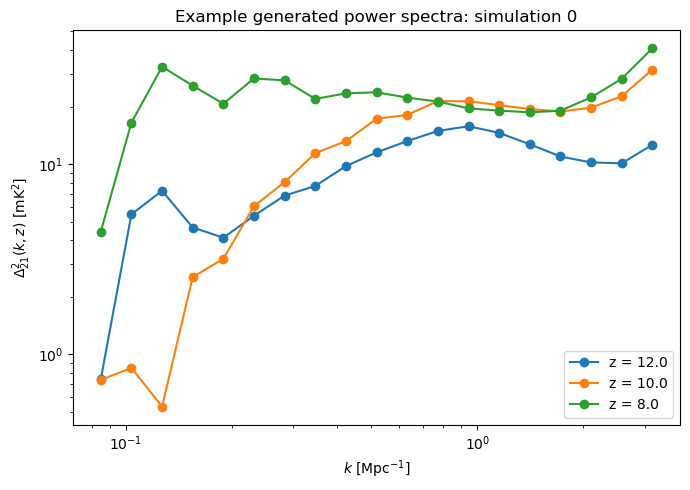

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/example_power_spectra_n100_validation.png


In [44]:
example_sim_id = int(power_df["simulation_id"].iloc[0])
example_df = power_df[power_df["simulation_id"] == example_sim_id]

plt.figure(figsize=(7, 5))

for z in sorted(example_df["z"].unique(), reverse=True):
    sub = example_df[example_df["z"] == z]

    plt.loglog(
        sub["k"],
        sub["delta2_21"],
        marker="o",
        label=f"z = {z:.1f}"
    )

plt.xlabel(r"$k$ [Mpc$^{-1}$]")
plt.ylabel(r"$\Delta^2_{21}(k,z)$ [mK$^2$]")
plt.title(f"Example generated power spectra: simulation {example_sim_id}")
plt.legend()
plt.tight_layout()

example_ps_path = FIGURES / f"example_power_spectra_{tag}.png"

plt.savefig(example_ps_path, dpi=300)
plt.show()

print("Saved figure to:", example_ps_path)

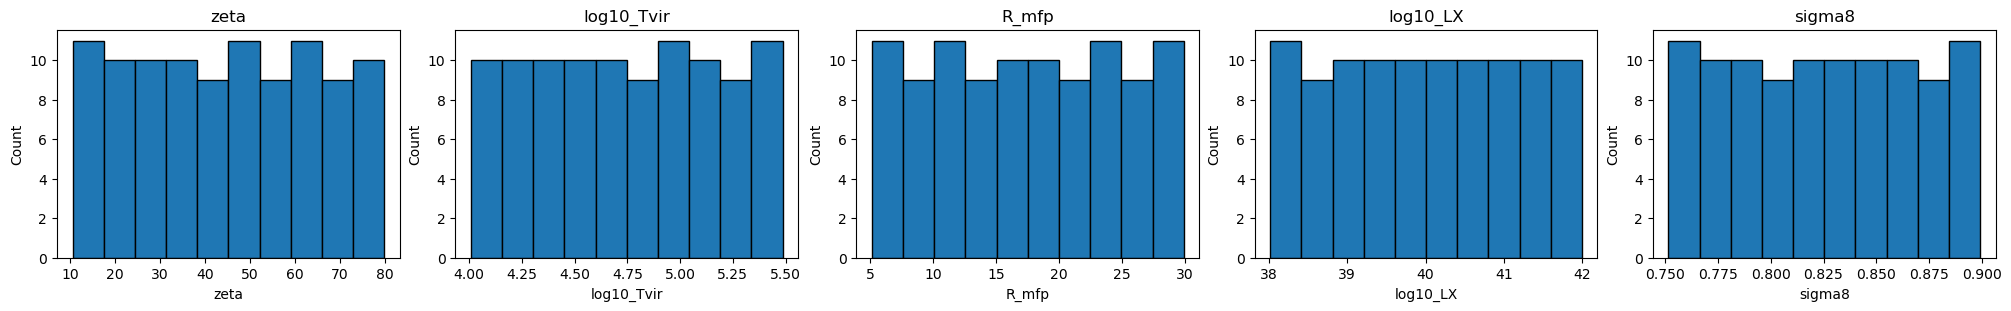

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/target_histograms_n100_validation.png


In [45]:
successful_target_df = pd.DataFrame(y, columns=target_names)

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(target_names),
    figsize=(4 * len(target_names), 3),
    constrained_layout=True
)

for ax, name in zip(axes, target_names):

    ax.hist(
        successful_target_df[name],
        bins=min(10, len(successful_target_df)),
        edgecolor="black"
    )

    ax.set_title(name)
    ax.set_xlabel(name)
    ax.set_ylabel("Count")

target_hist_path = FIGURES / f"target_histograms_{tag}.png"

plt.savefig(target_hist_path, dpi=300)
plt.show()

print("Saved figure to:", target_hist_path)

In [46]:
loaded_X = np.load(feature_matrix_path)
loaded_y = np.load(target_matrix_path)

loaded_power_df = pd.read_csv(power_spectra_path)
loaded_feature_names_df = pd.read_csv(feature_names_path)
loaded_target_names_df = pd.read_csv(target_names_path)

with open(metadata_path, "r") as f:
    loaded_metadata = json.load(f)

print("Loaded X shape:", loaded_X.shape)
print("Loaded y shape:", loaded_y.shape)
print("Loaded power df shape:", loaded_power_df.shape)
print("Loaded feature names shape:", loaded_feature_names_df.shape)
print("Loaded target names shape:", loaded_target_names_df.shape)

assert loaded_X.shape == X.shape
assert loaded_y.shape == y.shape

assert len(loaded_feature_names_df) == X.shape[1]
assert len(loaded_target_names_df) == y.shape[1]

assert loaded_metadata["successful_simulations"] == X.shape[0]

print("Reload validation successful.")

Loaded X shape: (100, 57)
Loaded y shape: (100, 5)
Loaded power df shape: (5700, 4)
Loaded feature names shape: (57, 2)
Loaded target names shape: (5, 2)
Reload validation successful.


In [47]:
print("=" * 60)
print("Notebook 03 completed successfully.")
print("=" * 60)

print("Generated validation dataset")
print("Successful simulations:", X.shape[0])
print("Failed simulations:", len(failed_simulations))

print("Feature matrix shape:", X.shape)
print("Target matrix shape:", y.shape)

print("Power-spectrum rows:", len(power_df))

print("\nGenerated files:")
print(" -", feature_matrix_path)
print(" -", target_matrix_path)
print(" -", power_spectra_path)
print(" -", feature_names_path)
print(" -", target_names_path)
print(" -", metadata_path)
print(" -", example_ps_path)
print(" -", target_hist_path)

Notebook 03 completed successfully.
Generated validation dataset
Successful simulations: 100
Failed simulations: 0
Feature matrix shape: (100, 57)
Target matrix shape: (100, 5)
Power-spectrum rows: 5700

Generated files:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/feature_matrix_n100_validation.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/target_matrix_n100_validation.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/power_spectra_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/feature_names_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/target_names_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/dataset_generation_metadata_n100_validation.json
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/example_power_spectra_n100_validati